<a href="https://www.kaggle.com/code/nithinreddy600/q12-market-research-component?scriptVersionId=322264385" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Q12 — Offshore RMB, Hong Kong and Other Financial Centres

**Question 12:** What does the offshore RMB data suggest about the role of Hong Kong and other financial centres?  
**Required output:** Short paragraph with one value or ranking.

**Dataset link used:** https://www.kaggle.com/datasets/nithinreddy600/dbs-research/data  
**Kaggle dataset slug:** `nithinreddy600/dbs-research`

This notebook properly loads the Kaggle dataset and makes sure the **table and chart clearly show the analysis period / data period used**.

Expected final outputs:
1. `Q12_offshore_RMB_financial_centres_table.csv`
2. `Q12_offshore_RMB_financial_centres_chart.png`
3. `Q12_final_answer.txt`


In [1]:
# ============================================================
# Q12: Load Kaggle dataset properly
# Dataset: https://www.kaggle.com/datasets/nithinreddy600/dbs-research/data
# ============================================================

import os
import re
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

KAGGLE_DATASET_SLUG = "nithinreddy600/dbs-research"

def resolve_dataset_root():
    """
    Finds the Kaggle dataset folder.

    On Kaggle:
    1. Open notebook
    2. Add Data
    3. Attach dataset: nithinreddy600/dbs-research
    4. Dataset should usually appear at /kaggle/input/dbs-research
    """
    exact_paths = [
        Path("/kaggle/input/dbs-research"),
        Path("/kaggle/input/dbs-research/data"),
    ]

    for path in exact_paths:
        if path.exists():
            return path

    kaggle_input = Path("/kaggle/input")
    if kaggle_input.exists():
        for path in kaggle_input.iterdir():
            if path.is_dir() and "dbs" in path.name.lower():
                return path

    try:
        import kagglehub
        downloaded_path = kagglehub.dataset_download(KAGGLE_DATASET_SLUG)
        return Path(downloaded_path)
    except Exception as e:
        raise RuntimeError(
            "Dataset folder was not found. On Kaggle, attach the dataset first: "
            "Add Data -> search 'nithinreddy600/dbs-research'."
        ) from e

DATASET_ROOT = resolve_dataset_root()
print("Dataset root:", DATASET_ROOT)

all_files = [p for p in DATASET_ROOT.rglob("*") if p.is_file()]
print("Total files found:", len(all_files))

for i, file in enumerate(all_files, start=1):
    print(f"{i:02d}. {file.relative_to(DATASET_ROOT)}")


Dataset root: /kaggle/input/datasets/nithinreddy600/dbs-research
Total files found: 5
01. Gold 100years.csv
02. Brent Oil.csv
03. silver 100 years.csv
04. swift_currency_tracker_all_reports.csv
05. global-currency-tracker-april-2026.pdf


In [2]:
# ============================================================
# Read CSV/Excel files and collect PDFs
# ============================================================

def read_csv_safely(path):
    encodings = ["utf-8", "utf-8-sig", "latin1", "cp1252"]
    for enc in encodings:
        try:
            return pd.read_csv(path, encoding=enc)
        except Exception:
            pass
    return None

def read_excel_safely(path):
    try:
        return pd.read_excel(path, sheet_name=None)
    except Exception:
        return None

loaded_tables = []

for file in all_files:
    suffix = file.suffix.lower()

    if suffix == ".csv":
        df = read_csv_safely(file)
        if df is not None and not df.empty:
            loaded_tables.append({"file": file, "sheet": None, "df": df})

    elif suffix in [".xlsx", ".xls"]:
        sheets = read_excel_safely(file)
        if sheets:
            for sheet_name, df in sheets.items():
                if df is not None and not df.empty:
                    loaded_tables.append({"file": file, "sheet": sheet_name, "df": df})

pdf_files = [p for p in all_files if p.suffix.lower() == ".pdf"]

print("Tables loaded:", len(loaded_tables))
for item in loaded_tables:
    print("TABLE:", item["file"].relative_to(DATASET_ROOT), "| sheet:", item["sheet"], "| shape:", item["df"].shape)

print("\nPDF files found:", len(pdf_files))
for file in pdf_files:
    print("PDF:", file.relative_to(DATASET_ROOT))


Tables loaded: 4
TABLE: Gold 100years.csv | sheet: None | shape: (1336, 3)
TABLE: Brent Oil.csv | sheet: None | shape: (963, 3)
TABLE: silver 100 years.csv | sheet: None | shape: (1336, 3)
TABLE: swift_currency_tracker_all_reports.csv | sheet: None | shape: (288, 9)

PDF files found: 1
PDF: global-currency-tracker-april-2026.pdf


In [3]:
# ============================================================
# Helper functions: detect period + extract offshore RMB data
# ============================================================

OFFSHORE_KEYWORDS = [
    "offshore", "rmb", "renminbi", "hong kong",
    "financial centre", "financial center", "payment weight",
    "top 15 offshore rmb"
]

CENTRE_NAMES = [
    "Hong Kong",
    "United Kingdom",
    "Singapore",
    "United States",
    "France",
    "Taiwan",
    "South Korea",
    "Macao",
    "Macau",
    "Japan",
    "Germany",
    "Australia",
    "Belgium",
    "Luxembourg",
    "Netherlands",
    "Canada"
]

MONTHS = (
    "January|February|March|April|May|June|July|August|September|October|November|December|"
    "Jan|Feb|Mar|Apr|Jun|Jul|Aug|Sep|Sept|Oct|Nov|Dec"
)

def normalize_text(x):
    return re.sub(r"\s+", " ", str(x).replace("\xa0", " ")).strip()

def detect_analysis_period_from_text(text):
    """
    Tries to detect the period used in the source text.
    Example expected text: 'Top 15 offshore RMB economies by weight – February 2026'
    """
    if not text:
        return None

    clean = normalize_text(text)

    # Strong pattern: "... by weight – February 2026" or "for February 2026"
    period_patterns = [
        rf"(?:by weight|data|period|month|for|as of|in)\s*[-–—:]?\s*({MONTHS})\s+(\d{{4}})",
        rf"({MONTHS})\s+(\d{{4}})"
    ]

    matches = []
    for pattern in period_patterns:
        matches += re.findall(pattern, clean, flags=re.IGNORECASE)

    if matches:
        month, year = matches[-1]
        month = month[:1].upper() + month[1:].lower()
        return f"{month} {year}"

    return None

def table_text(df):
    return " ".join(map(str, df.columns)) + " " + df.head(150).astype(str).to_string()

def score_dataframe_for_q12(df):
    combined = table_text(df).lower()
    return sum(keyword in combined for keyword in OFFSHORE_KEYWORDS)

def find_centre_column(df):
    best_col = None
    best_hits = 0

    for col in df.columns:
        values = df[col].astype(str).map(normalize_text)
        hits = 0
        for centre in CENTRE_NAMES:
            hits += values.str.contains(re.escape(centre), case=False, regex=True, na=False).sum()
        if hits > best_hits:
            best_hits = hits
            best_col = col

    return best_col if best_hits > 0 else None

def find_share_column(df, centre_col):
    candidates = []

    for col in df.columns:
        if col == centre_col:
            continue

        raw = df[col].astype(str).str.replace("%", "", regex=False).str.replace(",", "", regex=False)
        numeric = pd.to_numeric(raw, errors="coerce")
        valid_count = numeric.notna().sum()

        if valid_count == 0:
            continue

        between_0_100 = numeric.between(0, 100).sum()
        col_name_score = int(any(word in str(col).lower() for word in ["share", "weight", "%", "percent", "payment"]))
        score = between_0_100 + (5 * col_name_score)

        candidates.append((score, col, numeric))

    if not candidates:
        return None, None

    candidates.sort(key=lambda x: x[0], reverse=True)
    return candidates[0][1], candidates[0][2]

def extract_q12_from_tables(loaded_tables):
    candidates = []

    for item in loaded_tables:
        df = item["df"].copy()
        df.columns = [normalize_text(c) for c in df.columns]

        score = score_dataframe_for_q12(df)
        centre_col = find_centre_column(df)

        if score == 0 and centre_col is None:
            continue

        if centre_col is None:
            continue

        share_col, numeric_share = find_share_column(df, centre_col)
        if share_col is None:
            continue

        temp = pd.DataFrame({
            "Economy / Financial Centre": df[centre_col].astype(str).map(normalize_text),
            "Share (%)": numeric_share
        })

        mask = temp["Economy / Financial Centre"].apply(
            lambda x: any(re.search(re.escape(c), x, flags=re.IGNORECASE) for c in CENTRE_NAMES)
        )
        temp = temp[mask].dropna(subset=["Share (%)"])
        temp["Economy / Financial Centre"] = temp["Economy / Financial Centre"].replace({"Macau": "Macao"})
        temp = temp.drop_duplicates(subset=["Economy / Financial Centre"], keep="first")

        if len(temp) >= 3:
            temp = temp.sort_values("Share (%)", ascending=False).reset_index(drop=True)
            temp.insert(0, "Rank", range(1, len(temp) + 1))

            period_text = (
                str(item["file"].name) + " " +
                (str(item["sheet"]) if item["sheet"] else "") + " " +
                table_text(df)
            )
            detected_period = detect_analysis_period_from_text(period_text)

            candidates.append((score + len(temp), item["file"], item["sheet"], temp, detected_period))

    if not candidates:
        return None

    candidates.sort(key=lambda x: x[0], reverse=True)
    best_score, source_file, source_sheet, q12_df, detected_period = candidates[0]
    return {
        "source_type": "table",
        "source_file": source_file,
        "source_sheet": source_sheet,
        "q12_df": q12_df,
        "analysis_period": detected_period
    }


In [4]:
# ============================================================
# PDF fallback: read PDF text and detect the analysis period
# ============================================================

def extract_pdf_text(path):
    text_parts = []

    try:
        from pypdf import PdfReader
        reader = PdfReader(str(path))
        for page in reader.pages:
            text_parts.append(page.extract_text() or "")
        return "\n".join(text_parts)
    except Exception:
        pass

    try:
        import PyPDF2
        reader = PyPDF2.PdfReader(str(path))
        for page in reader.pages:
            text_parts.append(page.extract_text() or "")
        return "\n".join(text_parts)
    except Exception as e:
        print(f"Could not extract PDF text from {path.name}: {e}")
        return ""

def extract_q12_from_pdf_text(text):
    if not text:
        return None

    clean_text = text.replace("\xa0", " ")
    lines = [normalize_text(line) for line in clean_text.splitlines() if normalize_text(line)]

    keyword_text = clean_text.lower()
    if not ("rmb" in keyword_text and ("offshore" in keyword_text or "hong kong" in keyword_text)):
        return None

    results = []

    for centre in CENTRE_NAMES:
        centre_pattern = re.compile(re.escape(centre), flags=re.IGNORECASE)

        for line in lines:
            if not centre_pattern.search(line):
                continue

            numbers = re.findall(r"(?<!\d)(\d{1,3}(?:\.\d+)?)(?!\d)", line)
            possible_values = []

            for n in numbers:
                try:
                    value = float(n)
                    if 0 <= value <= 100:
                        possible_values.append(value)
                except Exception:
                    pass

            if possible_values:
                share = possible_values[-1]
                results.append({
                    "Economy / Financial Centre": "Macao" if centre == "Macau" else centre,
                    "Share (%)": share,
                    "Matched line": line
                })
                break

    if len(results) < 3:
        return None

    q12_df = pd.DataFrame(results)
    q12_df = q12_df.drop_duplicates(subset=["Economy / Financial Centre"], keep="first")
    q12_df = q12_df.sort_values("Share (%)", ascending=False).reset_index(drop=True)
    q12_df.insert(0, "Rank", range(1, len(q12_df) + 1))

    return q12_df

def extract_q12_from_pdfs(pdf_files):
    candidates = []

    for pdf_file in pdf_files:
        text = extract_pdf_text(pdf_file)
        text_lower = text.lower()

        score = sum(keyword in text_lower for keyword in OFFSHORE_KEYWORDS)
        if score == 0:
            continue

        q12_df = extract_q12_from_pdf_text(text)
        detected_period = detect_analysis_period_from_text(text)

        if q12_df is not None and len(q12_df) >= 3:
            candidates.append((score + len(q12_df), pdf_file, q12_df, detected_period))

    if not candidates:
        return None

    candidates.sort(key=lambda x: x[0], reverse=True)
    best_score, source_file, q12_df, detected_period = candidates[0]
    return {
        "source_type": "pdf",
        "source_file": source_file,
        "source_sheet": None,
        "q12_df": q12_df,
        "analysis_period": detected_period
    }


In [5]:
# ============================================================
# Build Q12 table from Kaggle dataset + include analysis period
# ============================================================

q12_result = extract_q12_from_tables(loaded_tables)

if q12_result is None:
    q12_result = extract_q12_from_pdfs(pdf_files)

if q12_result is None:
    print("Could not automatically extract the offshore RMB table.")
    print("\nFiles available in the dataset:")
    for file in all_files:
        print("-", file.relative_to(DATASET_ROOT))

    raise ValueError(
        "Q12 offshore RMB data was not found automatically. "
        "Open the listed files and identify which file contains 'Top 15 offshore RMB economies by weight'. "
        "If the table is inside an image-only PDF, manual OCR/conversion to CSV may be needed."
    )

q12_df = q12_result["q12_df"].copy()

# If the notebook cannot detect the period from the dataset text,
# write it manually here after checking the source report/table.
ANALYSIS_PERIOD = q12_result["analysis_period"] or "February 2026"

q12_top = q12_df.head(15).copy()
q12_top.insert(1, "Analysis Period", ANALYSIS_PERIOD)
q12_top["Source File"] = q12_result["source_file"].name

q12_top.to_csv("Q12_offshore_RMB_financial_centres_table.csv", index=False)

print("Q12 data source type:", q12_result["source_type"])
print("Q12 source file:", q12_result["source_file"].relative_to(DATASET_ROOT))
if q12_result["source_sheet"]:
    print("Q12 source sheet:", q12_result["source_sheet"])
print("Analysis period used:", ANALYSIS_PERIOD)

display(q12_top)


Q12 data source type: table
Q12 source file: swift_currency_tracker_all_reports.csv
Analysis period used: March 2026


,Rank,Analysis Period,Economy / Financial Centre,Share (%),Source File
0,1,March 2026,Hong Kong,74.55,swift_currency_tracker_all_reports.csv
1,2,March 2026,United Kingdom,7.04,swift_currency_tracker_all_reports.csv
2,3,March 2026,Singapore,4.39,swift_currency_tracker_all_reports.csv
3,4,March 2026,United States,2.68,swift_currency_tracker_all_reports.csv
4,5,March 2026,France,1.95,swift_currency_tracker_all_reports.csv
5,6,March 2026,Taiwan,1.43,swift_currency_tracker_all_reports.csv
6,7,March 2026,South Korea,1.31,swift_currency_tracker_all_reports.csv
7,8,March 2026,Australia,0.94,swift_currency_tracker_all_reports.csv
8,9,March 2026,Japan,0.81,swift_currency_tracker_all_reports.csv
9,10,March 2026,Germany,0.76,swift_currency_tracker_all_reports.csv


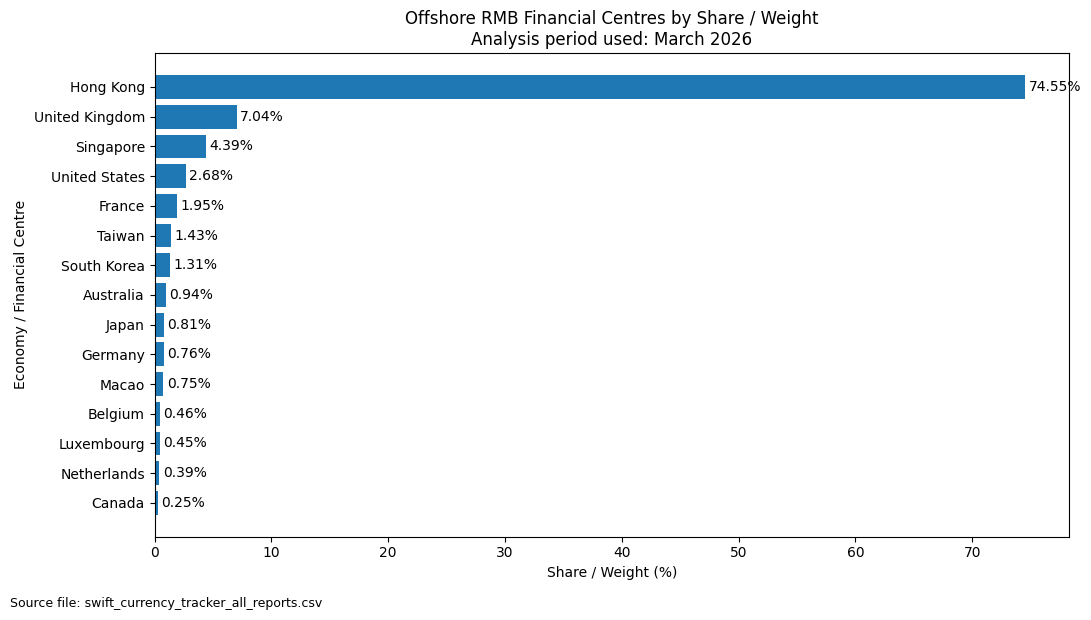

In [6]:
# ============================================================
# Create Q12 chart with analysis period in the title
# ============================================================

plt.figure(figsize=(11, 6))
plt.barh(q12_top["Economy / Financial Centre"], q12_top["Share (%)"])
plt.gca().invert_yaxis()

plt.title(f"Offshore RMB Financial Centres by Share / Weight\nAnalysis period used: {ANALYSIS_PERIOD}")
plt.xlabel("Share / Weight (%)")
plt.ylabel("Economy / Financial Centre")

for y, value in enumerate(q12_top["Share (%)"]):
    plt.text(value + 0.3, y, f"{value:.2f}%", va="center")

plt.figtext(
    0.01, -0.02,
    f"Source file: {q12_result['source_file'].name}",
    ha="left",
    fontsize=9
)

plt.tight_layout()
plt.savefig("Q12_offshore_RMB_financial_centres_chart.png", dpi=200, bbox_inches="tight")
plt.show()


In [7]:
# ============================================================
# Generate final short answer with the analysis period included
# ============================================================

top = q12_top.iloc[0]

if len(q12_top) >= 3:
    second = q12_top.iloc[1]
    third = q12_top.iloc[2]

    answer = (
        f"The offshore RMB data for {ANALYSIS_PERIOD} suggests that "
        f"{top['Economy / Financial Centre']} is the main offshore hub for RMB payments. "
        f"It ranks 1st with {top['Share (%)']:.2f}% of the offshore RMB share/weight, far above "
        f"{second['Economy / Financial Centre']} at {second['Share (%)']:.2f}% and "
        f"{third['Economy / Financial Centre']} at {third['Share (%)']:.2f}%. "
        f"This shows that offshore RMB activity is highly concentrated in {top['Economy / Financial Centre']}, "
        "while other financial centres play smaller supporting roles in the international use of RMB."
    )
else:
    answer = (
        f"The offshore RMB data for {ANALYSIS_PERIOD} suggests that "
        f"{top['Economy / Financial Centre']} is the main offshore RMB centre. "
        f"It ranks 1st with {top['Share (%)']:.2f}% of the recorded offshore RMB share/weight, showing strong concentration."
    )

print(answer)

with open("Q12_final_answer.txt", "w", encoding="utf-8") as f:
    f.write(answer)


The offshore RMB data for March 2026 suggests that Hong Kong is the main offshore hub for RMB payments. It ranks 1st with 74.55% of the offshore RMB share/weight, far above United Kingdom at 7.04% and Singapore at 4.39%. This shows that offshore RMB activity is highly concentrated in Hong Kong, while other financial centres play smaller supporting roles in the international use of RMB.


## Files created by this notebook

After running all cells, the notebook creates:

1. `Q12_offshore_RMB_financial_centres_table.csv`  
   - includes `Analysis Period`
   - includes `Source File`

2. `Q12_offshore_RMB_financial_centres_chart.png`  
   - chart title includes the analysis period used
   - chart footer includes source file name

3. `Q12_final_answer.txt`  
   - answer includes the analysis period
